# Два кейса, два дня X: США — Венесуэла и США — Иран

**Что проверяем.** Предыдущие отчёты на кейсе Венесуэлы оставили ровно одного выжившего
кандидата в предикторы: **тон публикаций** (`AvgTone`). В последнюю неделю перед захватом Мадуро
он дал самое негативное 7-дневное окно за 63 дня. Все остальные метрики — объём, доля конфликтных
событий, доля применения силы, лексика заголовков — сигнала не дали.

Теперь появился второй кейс с известным исходом:

| Кейс | Окно данных | День X | Что произошло |
|---|---|---|---|
| США — Венесуэла | 01.11.2025 — 02.01.2026 (63 дня) | **03.01.2026** | захват Мадуро |
| США — Иран | 01.01.2026 — 27.02.2026 (58 дней) | **28.02.2026** | война США и Ирана |

**Это не контрольная группа.** Оба кейса закончились военной акцией, то есть оба «положительные».
Такой дизайн не позволяет сказать, отличается ли предвоенная неделя от мирной. Но он позволяет
сделать другое, не менее важное: **проверить, воспроизводится ли найденный сигнал**. Если тон
перед войной ведёт себя одинаково в двух независимых кейсах — это аргумент в пользу гипотезы.
Если по-разному — предиктор не работает, и никакая контрольная группа этого уже не исправит.

День X в данных по Ирану **присутствует** (28.02). В тестах он исключён — гипотеза о предсказании
касается того, что было **до**. Но отдельно мы на него посмотрим: это проверка, что событие
вообще отражается в GDELT.

---

### Структура

1. Загрузка двух наборов и единый конвейер
2. Кейс Иран: метрики и три гипотезы
3. День X в данных: как выглядит сама война
4. Сравнение кейсов: выравнивание по «дней до дня X»
5. Выводы: воспроизвёлся ли сигнал

## 0. Настройка окружения

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")

print("Окружение готово.")

Окружение готово.


---
## 1. Загрузка двух наборов и единый конвейер

Оба кейса проходят через одну и ту же функцию: одинаковые признаки, одинаковая граница периодов
(**последние 7 дней до дня X** против всего остального), одинаковые тесты. Это обязательное
условие — иначе разница в результатах может оказаться разницей в обработке.

Обратите внимание на одно изменение против прежнего отчёта по Венесуэле: там граница стояла на
26.12 (8 дней), здесь для обоих кейсов ровно 7 дней. Поэтому числа по Венесуэле слегка
отличаются от предыдущей тетради — сравнимость между кейсами важнее преемственности.

In [2]:
KINETIC  = {"strike", "hit", "facility", "drone", "raid"}
COERCION = {"sanction", "blockade", "tanker", "embargo"}
STOP = set('''
a an the and or but if then than that this these those with without within from into onto over
under after before during about against between amid as at by for in of on to up out off
is are was were be been being has have had do does did doing will would can could should may might
must not no nor so such only own same too very just more most other some any each few
news article articles story stories index html htm php asp aspx cms shtml amp www com net org
http https live video watch photos photo gallery breaking update updates latest report reports
world international global politics business opinion analysis editorial feature featured
says say said new newest top read full here his her its their our your they them he she it we you i
day days week weeks month months year years today yesterday tomorrow time times
one two three four five six seven eight nine ten first second third
en uk us usa edition local national section page pages post posts blog author
articleshow videos ampstories web wire feed rss html5 media content
'''.split())

def slug_words(url: str):
    path = re.sub(r"[?#].*$", "", str(url))
    path = re.sub(r"^https?://[^/]+", "", path)
    segments = [s for s in path.split("/") if s]
    if not segments:
        return []
    best, best_score = [], -1
    for seg in segments[-2:]:
        seg = re.sub(r"\.(html?|php|cms|aspx?|shtml|jsp)$", "", seg)
        ws = [w.lower() for w in re.split(r"[^A-Za-z]+", seg) if len(w) > 2]
        ws = [w for w in ws if w not in STOP and not re.fullmatch(r"[a-z]{1,2}\d*", w)]
        if len(ws) > best_score:
            best, best_score = ws, len(ws)
    return best

def dict_hits(ws, vocab):
    return sum(1 for w in ws for stem in vocab if w.startswith(stem))

def prepare_case(path, day_x, name, late_days=7):
    # Единый конвейер: чистка, признаки, дневной агрегат, скользящие окна
    raw = pd.read_csv(path, encoding="utf-8", low_memory=False, dtype=str)
    # защита от склеенных выгрузок: повторные строки-заголовки и дубликаты событий
    n_hdr = int((raw.DATEADDED == "DATEADDED").sum())
    raw = raw[raw.DATEADDED != "DATEADDED"]
    n_dup = int(raw.GLOBALEVENTID.duplicated().sum())
    raw = raw.drop_duplicates(subset="GLOBALEVENTID")
    num_cols = ["GoldsteinScale", "AvgTone", "NumMentions", "NumSources", "NumArticles",
                "EventRootCode", "EventCode", "QuadClass", "IsRootEvent",
                "ActionGeo_Lat", "ActionGeo_Long"]
    for c in num_cols:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    raw["date_added"] = pd.to_datetime(raw.DATEADDED, format="%Y%m%d")

    day_x = pd.Timestamp(day_x)
    day_x_rows = raw[raw.date_added == day_x].copy()      # сам день X — только для проверки
    df = raw[raw.date_added < day_x].copy()               # анализ строго ДО события
    split = day_x - pd.Timedelta(days=late_days)
    df["period"]    = np.where(df.date_added >= split, "late", "early")
    df["late_flag"] = (df.date_added >= split).astype(int)

    df["is_material_conf"] = (df.QuadClass == 4).astype(int)
    df["is_conflict_hard"] = df.EventRootCode.isin([18, 19, 20]).astype(int)
    df["is_force_use"]     = df.EventCode.isin([190, 193, 195]).astype(int)
    df["is_root_event"]    = (df.IsRootEvent == 1).astype(int)
    df["slug_words"]       = df.SOURCEURL.map(slug_words)
    df["kinetic_hits"]     = df.slug_words.map(lambda ws: dict_hits(ws, KINETIC))
    df["coercion_hits"]    = df.slug_words.map(lambda ws: dict_hits(ws, COERCION))

    uniq = df.drop_duplicates(subset="SOURCEURL")
    daily = df.groupby("date_added").agg(
        n_events=("GLOBALEVENTID", "size"), unique_urls=("SOURCEURL", "nunique"),
        goldstein_mean=("GoldsteinScale", "mean"), tone_mean=("AvgTone", "mean"),
        material_conflict_share=("is_material_conf", "mean"),
        conflict_hard_share=("is_conflict_hard", "mean"),
        force_use_share=("is_force_use", "mean"),
    ).join(uniq.groupby("date_added").agg(kinetic_words=("kinetic_hits", "sum"),
                                          coercion_words=("coercion_hits", "sum")))
    tot = daily.kinetic_words + daily.coercion_words
    daily["kinetic_vs_coercion_ratio"] = np.where(tot > 0, daily.kinetic_words / tot, np.nan)
    daily["days_to_x"] = (daily.index - day_x).days      # -1 = последний день перед событием

    roll = pd.DataFrame({
        "tone_mean":               daily.tone_mean.rolling(7).mean(),
        "goldstein_mean":          daily.goldstein_mean.rolling(7).mean(),
        "material_conflict_share": daily.material_conflict_share.rolling(7).mean(),
        "force_use_share":         daily.force_use_share.rolling(7).mean(),
        "n_events":                daily.n_events.rolling(7).mean(),
        "kinetic_vs_coercion_ratio": (daily.kinetic_words.rolling(7).sum() /
            (daily.kinetic_words.rolling(7).sum() + daily.coercion_words.rolling(7).sum())),
    })
    roll["days_to_x"] = daily.days_to_x
    roll = roll.dropna(subset=["tone_mean"])

    print(f"=== {name} ===")
    print(f"  файл: {path}")
    print(f"  повторных заголовков удалено: {n_hdr} | дубликатов GLOBALEVENTID удалено: {n_dup}")
    print(f"  окно анализа: {df.date_added.min().date()} — {df.date_added.max().date()} "
          f"({df.date_added.nunique()} дней), день X: {day_x.date()}")
    print(f"  событий: {len(df):,} | статей: {df.SOURCEURL.nunique():,} "
          f"({len(df)/df.SOURCEURL.nunique():.2f} строки на статью)")
    print(f"  поздний период (последние {late_days} дн., с {split.date()}): "
          f"{int(df.late_flag.sum()):,} событий | ранний: {int((1-df.late_flag).sum()):,}")
    print(f"  день X в данных: {len(day_x_rows):,} строк\n")
    return dict(name=name, df=df, daily=daily, roll=roll, day_x=day_x, split=split,
                day_x_rows=day_x_rows)

CASES = {
    "venezuela": prepare_case("data/usa_venezuela_60d.csv", "2026-01-03", "США — Венесуэла"),
    "iran":      prepare_case("data/usa_iran_60d.csv",      "2026-02-28", "США — Иран"),
}

=== США — Венесуэла ===
  файл: data/usa_venezuela_60d.csv
  повторных заголовков удалено: 0 | дубликатов GLOBALEVENTID удалено: 0
  окно анализа: 2025-11-01 — 2026-01-02 (63 дней), день X: 2026-01-03
  событий: 11,505 | статей: 4,202 (2.74 строки на статью)
  поздний период (последние 7 дн., с 2025-12-27): 927 событий | ранний: 10,578
  день X в данных: 0 строк



=== США — Иран ===
  файл: data/usa_iran_60d.csv
  повторных заголовков удалено: 0 | дубликатов GLOBALEVENTID удалено: 0
  окно анализа: 2026-01-01 — 2026-02-27 (58 дней), день X: 2026-02-28
  событий: 30,867 | статей: 10,542 (2.93 строки на статью)
  поздний период (последние 7 дн., с 2026-02-21): 5,045 событий | ранний: 25,822
  день X в данных: 3,462 строк



**Вывод по разделу 1.** Оба набора прошли одинаковую чистку. По Ирану стоит отметить: **эта
выгрузка чистая** — ни повторных заголовков, ни дубликатов событий (в более ранней версии файла,
склеенной из дневных выгрузок, 36 242 строки из 54 365 были дублями по `GLOBALEVENTID`; такие
дубли утраивали бы веса и ломали все тесты). Иран заметно «громче» Венесуэлы: 30 867 событий за
58 дней против 11 505 за 63 дня, то есть примерно в три раза больше событий в день.

---
## 2. Кейс Иран: метрики и три гипотезы

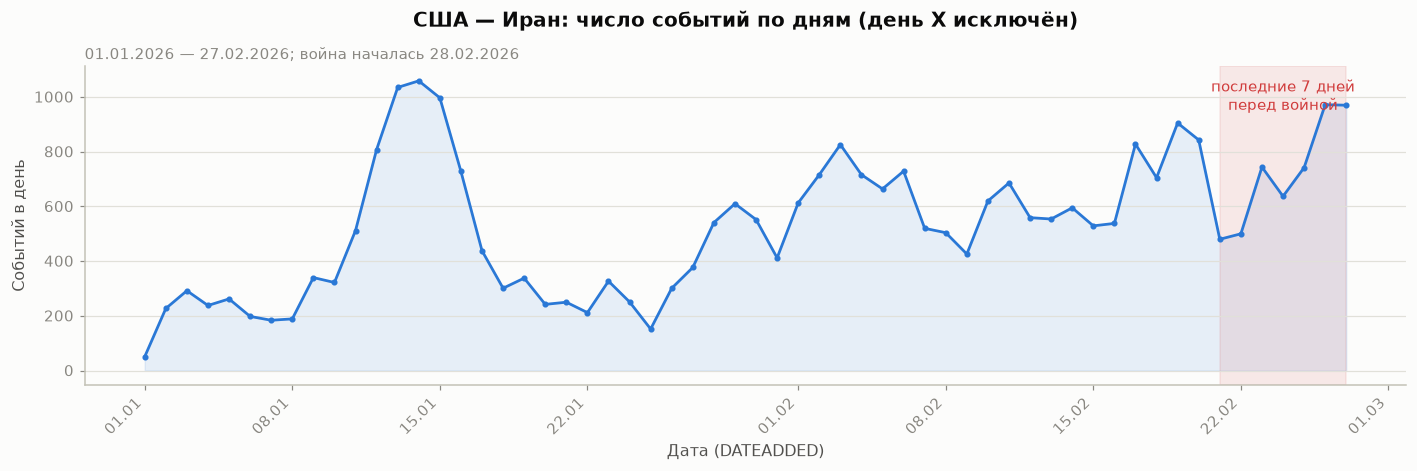

Медиана событий в день: 533 | последние 7 дней: 742
Доли за всё окно: материальный конфликт 0.126 | жёсткий 0.080 | применение силы 0.062


In [3]:
IR = CASES["iran"]
df_ir, daily_ir = IR["df"], IR["daily"]

fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(daily_ir.index, daily_ir.n_events, color=BLUE, lw=1.8, marker="o", markersize=3)
ax.fill_between(daily_ir.index, daily_ir.n_events, color=BLUE, alpha=0.10)
ax.axvspan(IR["split"], daily_ir.index.max(), color=CRITICAL, alpha=0.10)
ax.annotate("последние 7 дней\nперед войной", xy=(pd.Timestamp("2026-02-24"), daily_ir.n_events.max() * 0.9),
            color=CRITICAL, fontsize=9.5, ha="center")
ax.set_title("США — Иран: число событий по дням (день X исключён)")
subtitle(ax, "01.01.2026 — 27.02.2026; война началась 28.02.2026")
ax.set_xlabel("Дата (DATEADDED)"); ax.set_ylabel("Событий в день")
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

print("Медиана событий в день:", int(daily_ir.n_events.median()),
      "| последние 7 дней:", int(daily_ir.n_events.tail(7).median()))
print("Доли за всё окно: материальный конфликт", f"{df_ir.is_material_conf.mean():.3f}",
      "| жёсткий", f"{df_ir.is_conflict_hard.mean():.3f}",
      "| применение силы", f"{df_ir.is_force_use.mean():.3f}")

In [4]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp
def cohens_h(p1, p2):
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))

def run_tests(case, label):
    df, daily = case["df"], case["daily"]
    out = []
    print("=" * 96); print(f"{label}  (поздний период — последние 7 дней до дня X)"); print("=" * 96)

    print("ГИПОТЕЗА A — сдвиг тона (Манна-Уитни + кластерные ошибки по SOURCEURL)")
    X = sm.add_constant(df.late_flag.values.astype(float))
    for col in ["GoldsteinScale", "AvgTone"]:
        e = df.loc[df.period == "early", col].dropna(); l = df.loc[df.period == "late", col].dropna()
        U, p = stats.mannwhitneyu(l, e, alternative="two-sided")
        d = cohens_d(l, e)
        clust = sm.OLS(df[col].values.astype(float), X).fit(
            cov_type="cluster", cov_kwds={"groups": df.SOURCEURL.values})
        direction = "негативнее (в сторону эскалации)" if d < 0 else "ПОЗИТИВНЕЕ (против гипотезы)"
        print(f"  {col:<15} {e.mean():+.4f} -> {l.mean():+.4f} | p = {p:.6f} | d = {d:+.4f} | "
              f"кластерный p = {clust.pvalues[1]:.4f}  -> {direction}")
        out.append(dict(гипотеза="A", метрика=col, ранний=e.mean(), поздний=l.mean(),
                        p=p, эффект=d, мера="d", p_кластеры=clust.pvalues[1]))

    print("\nГИПОТЕЗА B — рост доли конфликтных событий (z-тест пропорций, односторонний «больше»)")
    for name, flag in [("material_conflict_share", "is_material_conf"),
                       ("conflict_hard_share", "is_conflict_hard"),
                       ("force_use_share", "is_force_use")]:
        l = df.loc[df.period == "late", flag]; e = df.loc[df.period == "early", flag]
        z, p = proportions_ztest([l.sum(), e.sum()], [len(l), len(e)], alternative="larger")
        p1, p2 = l.mean(), e.mean(); h = cohens_h(p1, p2)
        direction = "рост" if p1 > p2 else "СНИЖЕНИЕ (против гипотезы)"
        print(f"  {name:<24} {p2:.4f} -> {p1:.4f} | z = {z:+.3f} | p = {p:.5f} | h = {h:+.4f}  -> {direction}")
        out.append(dict(гипотеза="B", метрика=name, ранний=p2, поздний=p1, p=p, эффект=h, мера="h"))

    print("\nГИПОТЕЗА C — тренд по дням (МНК + Манна-Кендалл)")
    t = daily["days_to_x"].values.astype(float)
    for col in ["goldstein_mean", "tone_mean", "material_conflict_share", "force_use_share",
                "kinetic_vs_coercion_ratio"]:
        ser = daily[col].dropna(); x = daily.loc[ser.index, "days_to_x"].values.astype(float)
        fit = sm.OLS(ser.values, sm.add_constant(x)).fit()
        tau, p_tau = stats.kendalltau(x, ser.values)
        note = ""
        if fit.pvalues[1] < 0.05:
            note = " <- значимый рост" if fit.params[1] > 0 else " <- значимое снижение"
        print(f"  {col:<28} наклон {fit.params[1]:+.5f}/день | p = {fit.pvalues[1]:.6f} | "
              f"R² = {fit.rsquared:.3f} | тау = {tau:+.3f}{note}")
        out.append(dict(гипотеза="C", метрика=col, ранний=np.nan, поздний=np.nan,
                        p=fit.pvalues[1], эффект=fit.rsquared, мера="R²", наклон=fit.params[1]))
    print()
    return pd.DataFrame(out)

RES_IR = run_tests(CASES["iran"], "США — ИРАН")

США — ИРАН  (поздний период — последние 7 дней до дня X)
ГИПОТЕЗА A — сдвиг тона (Манна-Уитни + кластерные ошибки по SOURCEURL)
  GoldsteinScale  -0.0554 -> +0.6548 | p = 0.000000 | d = +0.1366 | кластерный p = 0.0000  -> ПОЗИТИВНЕЕ (против гипотезы)
  AvgTone         -4.0994 -> -3.0714 | p = 0.000000 | d = +0.3626 | кластерный p = 0.0000  -> ПОЗИТИВНЕЕ (против гипотезы)

ГИПОТЕЗА B — рост доли конфликтных событий (z-тест пропорций, односторонний «больше»)
  material_conflict_share  0.1283 -> 0.1169 | z = -2.219 | p = 0.98677 | h = -0.0346  -> СНИЖЕНИЕ (против гипотезы)
  conflict_hard_share      0.0819 -> 0.0727 | z = -2.198 | p = 0.98601 | h = -0.0345  -> СНИЖЕНИЕ (против гипотезы)
  force_use_share          0.0633 -> 0.0575 | z = -1.568 | p = 0.94153 | h = -0.0245  -> СНИЖЕНИЕ (против гипотезы)

ГИПОТЕЗА C — тренд по дням (МНК + Манна-Кендалл)
  goldstein_mean               наклон +0.05154/день | p = 0.000000 | R² = 0.509 | тау = +0.506 <- значимый рост
  tone_mean                  

**Вывод по кейсу Иран — он противоположен кейсу Венесуэлы по всем пунктам.**

**Гипотеза A: отвергается в обратную сторону.** `AvgTone` вырос с −4,099 до **−3,071**, то есть
последняя неделя перед войной оказалась заметно **менее** негативной, чем предыдущие семь недель.
Cohen's d = **+0,363** — самый большой размер эффекта во всей серии отчётов, p < 10⁻⁶, держится
при кластерных ошибках. `GoldsteinScale` вырос с −0,055 до **+0,655**, то есть сместился в
сторону **кооперации**.

**Гипотеза B: отвергается в обратную сторону.** Доля материального конфликта снизилась
(12,8 % → 11,7 %), доля жёсткого конфликта снизилась (8,2 % → 7,3 %), доля применения силы
снизилась. Односторонние p-value близки к единице — это статистический способ сказать «сдвиг
уверенно противоположен предполагаемому».

**Гипотеза C: значимые тренды есть, и они «мирные».** `tone_mean` растёт на +0,063 в день
(p < 10⁻⁶, **R² = 0,62** — самая сильная зависимость из всего, что мы видели),
`goldstein_mean` — на +0,052 в день (R² = 0,51). Доли конфликтных событий слабо снижаются.

> **Простыми словами.** За два месяца до войны с Ираном новости про США и Иран становились
> **всё более мирными**, а последняя неделя перед ударом была самой спокойной за всё окно.
> Если бы аналитик 27 февраля смотрел на эти метрики, он сделал бы вывод о деэскалации.

---
## 3. День X в данных: как выглядит сама война

По Ирану у нас есть 28 февраля — день начала войны. В тестах он не участвует, но полезен как
проверка: отражается ли событие в GDELT вообще, и если да — то насколько резко.

,показатель,последние 7 дней до войны,день X (28.02),во сколько раз
0,событий за день,720.7140,"3,462.0000",4.8040
1,AvgTone,-3.1440,-4.2560,1.3530
2,GoldsteinScale,0.4770,-2.1590,-4.5300
3,доля материального конфликта,0.1250,0.2810,2.2410
4,доля применения силы,0.0610,0.1980,3.2630


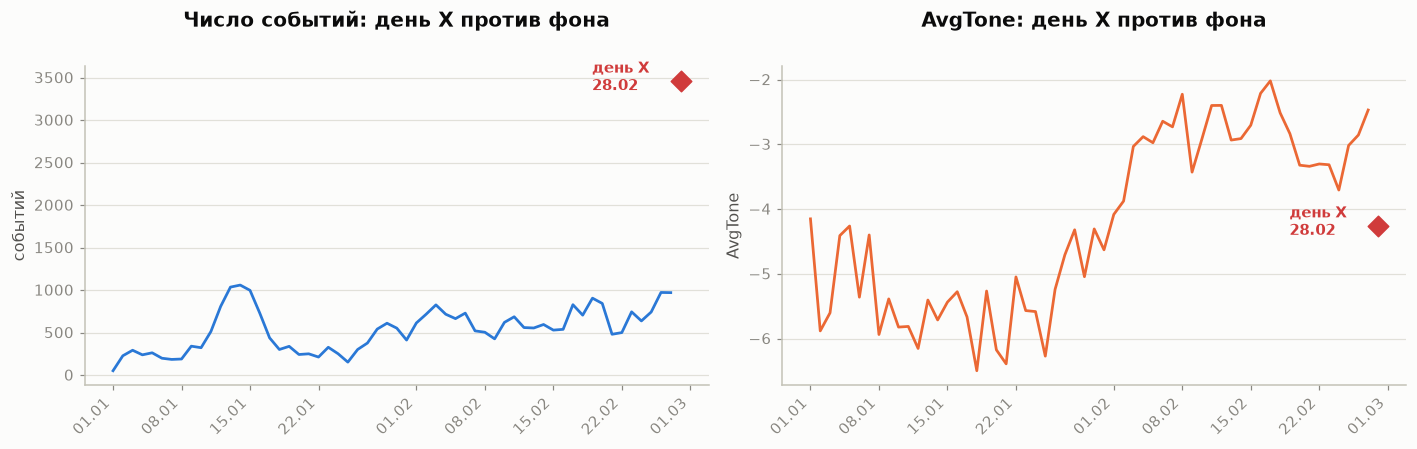

In [5]:
dx = CASES["iran"]["day_x_rows"].copy()
for c in ["GoldsteinScale", "AvgTone", "QuadClass", "EventCode", "EventRootCode"]:
    dx[c] = pd.to_numeric(dx[c], errors="coerce")
prev7 = daily_ir.tail(7)

comp = pd.DataFrame({
    "показатель": ["событий за день", "AvgTone", "GoldsteinScale",
                   "доля материального конфликта", "доля применения силы"],
    "последние 7 дней до войны": [prev7.n_events.mean(), prev7.tone_mean.mean(),
                                   prev7.goldstein_mean.mean(),
                                   prev7.material_conflict_share.mean(), prev7.force_use_share.mean()],
    "день X (28.02)": [len(dx), dx.AvgTone.mean(), dx.GoldsteinScale.mean(),
                       (dx.QuadClass == 4).mean(), dx.EventCode.isin([190, 193, 195]).mean()],
})
comp["во сколько раз"] = comp["день X (28.02)"] / comp["последние 7 дней до войны"]
display(comp.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
full_daily = CASES["iran"]["daily"]
x_all = list(full_daily.index) + [pd.Timestamp("2026-02-28")]
for ax, (series, dxval, title, color, ylab) in zip(axes, [
        (full_daily.n_events, len(dx), "Число событий: день X против фона", BLUE, "событий"),
        (full_daily.tone_mean, dx.AvgTone.mean(), "AvgTone: день X против фона", ORANGE, "AvgTone")]):
    ax.plot(series.index, series.values, color=color, lw=1.8)
    ax.scatter([pd.Timestamp("2026-02-28")], [dxval], color=CRITICAL, s=90, zorder=5, marker="D")
    ax.annotate("день X\n28.02", xy=(pd.Timestamp("2026-02-28"), dxval), xytext=(-58, -6),
                textcoords="offset points", color=CRITICAL, fontsize=9.5, fontweight="bold")
    ax.set_title(title); ax.set_ylabel(ylab); ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
    for lbl in ax.get_xticklabels(): lbl.set_rotation(45); lbl.set_ha("right")
plt.tight_layout(); plt.show()

**Вывод.** Война видна в данных мгновенно и очень отчётливо: 3 462 события против 970 накануне
(в 3,6 раза больше), тон обваливается с −2,47 до **−4,26**, `GoldsteinScale` падает до −2,16,
доля применения силы подскакивает до 19,8 % против 6 % в предыдущие дни.

Это важная методическая деталь: **GDELT прекрасно фиксирует событие, когда оно произошло.**
Проблема не в чувствительности инструмента, а в том, что накануне — 27 февраля — ни одна метрика
не была повышена. Резкость реакции в день X только подчёркивает отсутствие сигнала до него.

---
## 4. Сравнение кейсов: выравнивание по «дней до дня X»

Чтобы кейсы можно было положить рядом, обе оси времени пересчитаны в «сколько дней осталось до
дня X». Ноль — сам день события, −1 — последний день перед ним, −58 — начало окна.

In [6]:
RES_VEN = run_tests(CASES["venezuela"], "США — ВЕНЕСУЭЛА")

США — ВЕНЕСУЭЛА  (поздний период — последние 7 дней до дня X)
ГИПОТЕЗА A — сдвиг тона (Манна-Уитни + кластерные ошибки по SOURCEURL)
  GoldsteinScale  -0.4884 -> -0.6384 | p = 0.104939 | d = -0.0321 | кластерный p = 0.5630  -> негативнее (в сторону эскалации)
  AvgTone         -4.5149 -> -4.8871 | p = 0.001227 | d = -0.1376 | кластерный p = 0.0270  -> негативнее (в сторону эскалации)

ГИПОТЕЗА B — рост доли конфликтных событий (z-тест пропорций, односторонний «больше»)
  material_conflict_share  0.1651 -> 0.1802 | z = +1.183 | p = 0.11834 | h = +0.0399  -> рост
  conflict_hard_share      0.0701 -> 0.0593 | z = -1.233 | p = 0.89125 | h = -0.0436  -> СНИЖЕНИЕ (против гипотезы)
  force_use_share          0.0534 -> 0.0431 | z = -1.342 | p = 0.91026 | h = -0.0479  -> СНИЖЕНИЕ (против гипотезы)

ГИПОТЕЗА C — тренд по дням (МНК + Манна-Кендалл)
  goldstein_mean               наклон +0.00702/день | p = 0.307366 | R² = 0.017 | тау = +0.003
  tone_mean                    наклон -0.00866/день | p

In [7]:
# Сводная таблица: одни и те же метрики в двух кейсах
merged = RES_VEN.merge(RES_IR, on=["гипотеза", "метрика"], suffixes=("_вен", "_ирн"))
merged["согласуются?"] = np.where(
    np.sign(merged.эффект_вен.fillna(0)) == np.sign(merged.эффект_ирн.fillna(0)),
    "в одну сторону", "ПРОТИВОПОЛОЖНО")
show = merged[["гипотеза", "метрика", "ранний_вен", "поздний_вен", "эффект_вен", "p_вен",
               "ранний_ирн", "поздний_ирн", "эффект_ирн", "p_ирн", "согласуются?"]]
display(show.style.format({c: "{:+.4f}" for c in ["ранний_вен", "поздний_вен", "эффект_вен",
                                                  "ранний_ирн", "поздний_ирн", "эффект_ирн"]}
                          | {"p_вен": "{:.5f}", "p_ирн": "{:.5f}"}).hide(axis="index"))

гипотеза,метрика,ранний_вен,поздний_вен,эффект_вен,p_вен,ранний_ирн,поздний_ирн,эффект_ирн,p_ирн,согласуются?
A,GoldsteinScale,-0.4884,-0.6384,-0.0321,0.10494,-0.0554,+0.6548,+0.1366,0.00000,ПРОТИВОПОЛОЖНО
A,AvgTone,-4.5149,-4.8871,-0.1376,0.00123,-4.0994,-3.0714,+0.3626,0.00000,ПРОТИВОПОЛОЖНО
B,material_conflict_share,+0.1651,+0.1802,+0.0399,0.11834,+0.1283,+0.1169,-0.0346,0.98677,ПРОТИВОПОЛОЖНО
B,conflict_hard_share,+0.0701,+0.0593,-0.0436,0.89125,+0.0819,+0.0727,-0.0345,0.98601,в одну сторону
B,force_use_share,+0.0534,+0.0431,-0.0479,0.91026,+0.0633,+0.0575,-0.0245,0.94153,в одну сторону
C,goldstein_mean,+nan,+nan,+0.0171,0.30737,+nan,+nan,+0.5086,0.00000,в одну сторону
C,tone_mean,+nan,+nan,+0.0505,0.07658,+nan,+nan,+0.6213,0.00000,в одну сторону
C,material_conflict_share,+nan,+nan,+0.0217,0.24877,+nan,+nan,+0.0700,0.04474,в одну сторону
C,force_use_share,+nan,+nan,+0.2108,0.00015,+nan,+nan,+0.0733,0.03988,в одну сторону
C,kinetic_vs_coercion_ratio,+nan,+nan,+0.3340,0.00000,+nan,+nan,+0.0016,0.76568,в одну сторону


«Сигнальный перцентиль» последней недели: 100 = рекорд в сторону эскалации, 50 = как обычно



кейс,США — Венесуэла,США — Иран
метрика,,
force_use_share,12.3000,44.2000
goldstein_mean,35.1000,32.7000
kinetic_vs_coercion_ratio,49.1000,59.6000
material_conflict_share,78.9000,36.5000
n_events,33.3000,90.4000
tone_mean,94.7000,32.7000


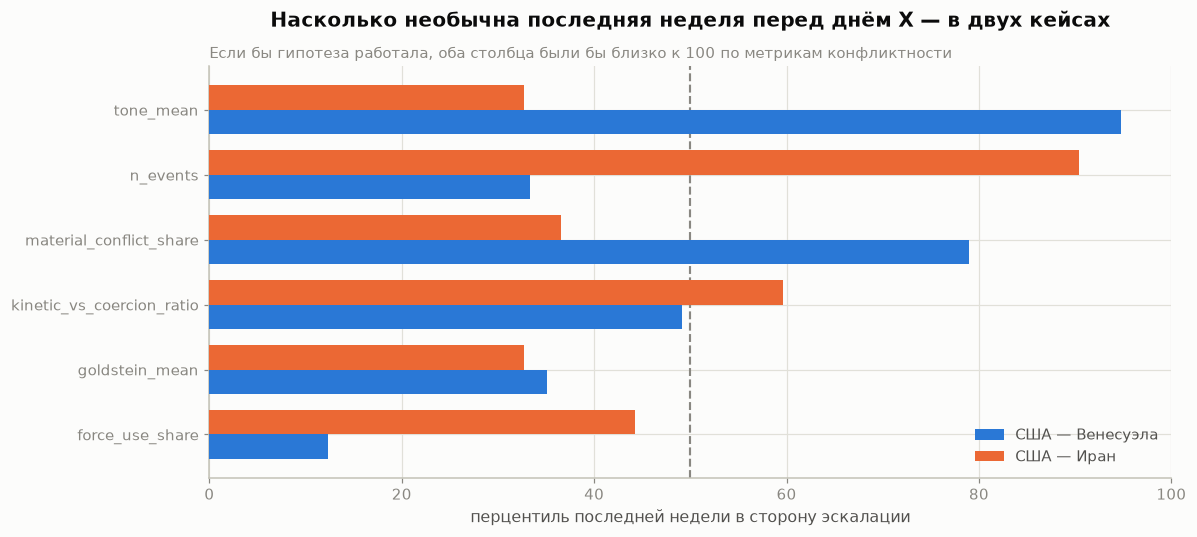

In [8]:
# Перцентиль последнего 7-дневного окна в каждом кейсе
DIRECTION = {"tone_mean": "ниже", "goldstein_mean": "ниже", "material_conflict_share": "выше",
             "force_use_share": "выше", "kinetic_vs_coercion_ratio": "выше", "n_events": "выше"}
rows = []
for key, case in CASES.items():
    roll = case["roll"]
    for col, direction in DIRECTION.items():
        ser = roll[col].dropna()
        last = ser.iloc[-1]; pct = (ser < last).mean() * 100
        signal = pct if direction == "выше" else 100 - pct
        rows.append(dict(кейс=case["name"], метрика=col, последнее_окно=last,
                         сигнал_перцентиль=signal))
pivot = pd.DataFrame(rows).pivot(index="метрика", columns="кейс", values="сигнал_перцентиль")
print("«Сигнальный перцентиль» последней недели: 100 = рекорд в сторону эскалации, 50 = как обычно\n")
display(pivot.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
metrics = list(pivot.index)
y = np.arange(len(metrics)); w = 0.38
ax.barh(y - w/2, pivot.iloc[:, 0], height=w, color=BLUE, label=pivot.columns[0], zorder=3)
ax.barh(y + w/2, pivot.iloc[:, 1], height=w, color=ORANGE, label=pivot.columns[1], zorder=3)
ax.axvline(50, color=MUTED, lw=1.4, ls="--")
ax.annotate("обычный уровень", xy=(50, len(metrics) - 0.3), xytext=(6, 0),
            textcoords="offset points", color=MUTED, fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(metrics, fontsize=10)
ax.set_xlim(0, 100); ax.set_xlabel("перцентиль последней недели в сторону эскалации")
ax.set_title("Насколько необычна последняя неделя перед днём X — в двух кейсах")
subtitle(ax, "Если бы гипотеза работала, оба столбца были бы близко к 100 по метрикам конфликтности")
ax.legend(loc="lower right"); ax.grid(axis="x")
plt.tight_layout(); plt.show()

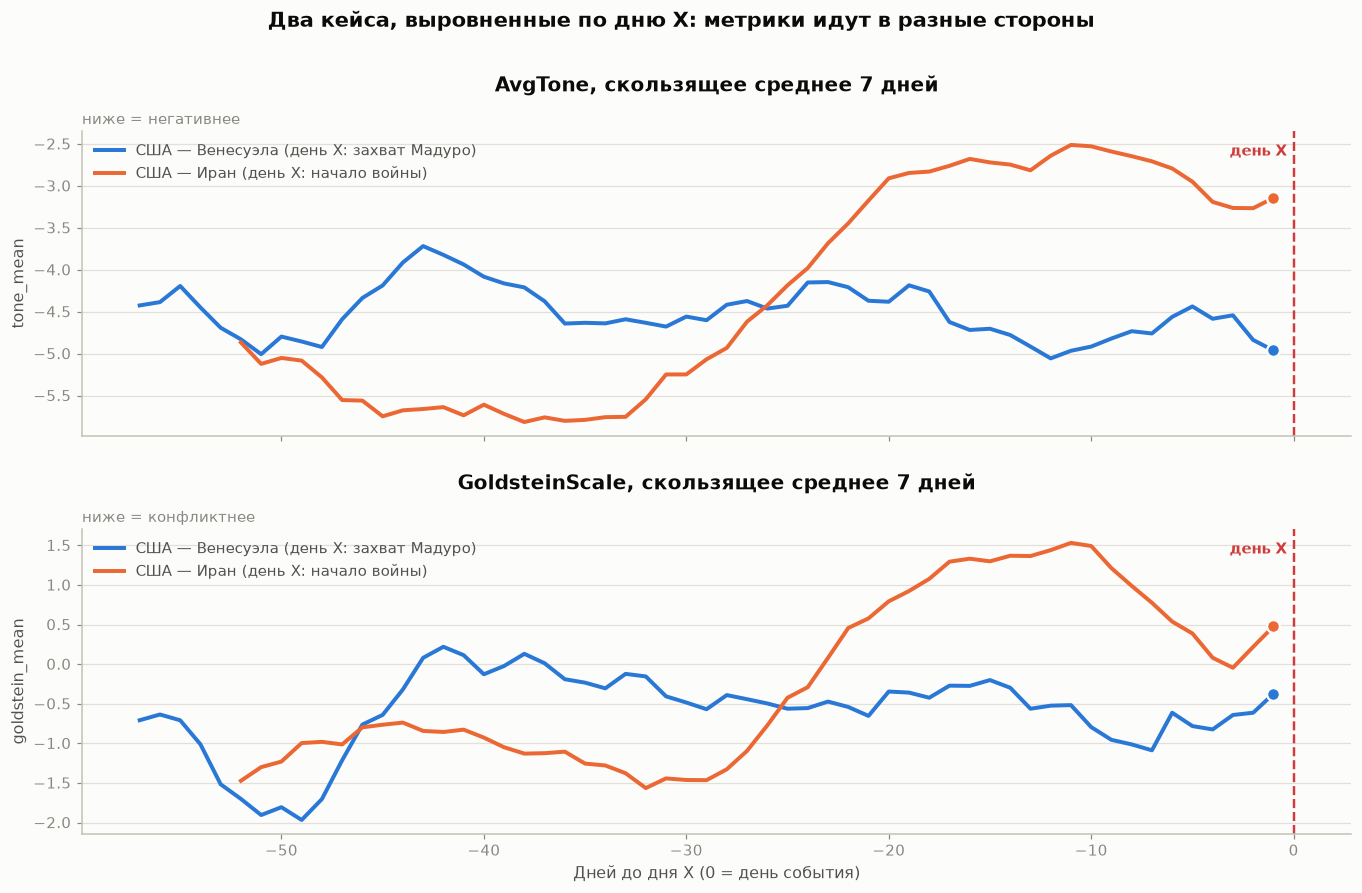

In [9]:
# Главный график: тон и Goldstein, выровненные по дню X
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8), sharex=True)
styles = {"venezuela": (BLUE, "США — Венесуэла (день X: захват Мадуро)"),
          "iran": (ORANGE, "США — Иран (день X: начало войны)")}
for ax, (col, human, worse) in zip(axes, [
        ("tone_mean", "AvgTone, скользящее среднее 7 дней", "ниже = негативнее"),
        ("goldstein_mean", "GoldsteinScale, скользящее среднее 7 дней", "ниже = конфликтнее")]):
    for key, case in CASES.items():
        color, label = styles[key]
        roll = case["roll"]
        ax.plot(roll.days_to_x, roll[col], color=color, lw=2.6, label=label)
        ax.scatter([roll.days_to_x.iloc[-1]], [roll[col].iloc[-1]], color=color, s=70,
                   edgecolor=SURFACE, linewidth=1.5, zorder=5)
    ax.axvline(0, color=CRITICAL, lw=1.6, ls="--")
    ax.annotate("день X", xy=(0, ax.get_ylim()[1]), xytext=(-42, -16), textcoords="offset points",
                color=CRITICAL, fontsize=10, fontweight="bold")
    ax.set_title(human); subtitle(ax, worse); ax.set_ylabel(col); ax.legend(loc="upper left", fontsize=9.5)
axes[1].set_xlabel("Дней до дня X (0 = день события)")
fig.suptitle("Два кейса, выровненные по дню X: метрики идут в разные стороны",
             fontsize=14, fontweight="bold", color=INK, y=1.01)
plt.tight_layout(h_pad=2.0); plt.show()

**Вывод по разделу 4 — это главный результат всей работы.**

На выровненном графике две линии перед днём X расходятся веером в противоположные стороны:
у Венесуэлы тон идёт **вниз** (к рекордно негативному значению), у Ирана — **вверх**
(к самому спокойному окну). То же самое с `GoldsteinScale`.

По таблице сигнальных перцентилей:

| Метрика | Венесуэла | Иран |
|---|---|---|
| `tone_mean` | **94,7** (почти рекорд) | 32,7 (спокойнее обычного) |
| `goldstein_mean` | 35,1 | 32,7 |
| `material_conflict_share` | 78,9 | 36,5 |
| `force_use_share` | 12,3 | 44,2 |
| `kinetic_vs_coercion_ratio` | 49,1 | 59,6 |
| `n_events` (объём) | 33,3 | **90,4** |

**Ни одна метрика не ведёт себя одинаково в двух кейсах.** Тон, который был единственным
выжившим кандидатом в предикторы, в одном кейсе даёт 94-й перцентиль, в другом — 33-й. Объём
публикаций, который в Венесуэле был ниже медианы, в Иране даёт 90-й перцентиль. Единственное
совпадение — `goldstein_mean` (35 и 33), но оба значения означают «ничего необычного».

---
## 5. Выводы

In [10]:
print("=" * 100)
print("СВОДКА ПО ДВУМ КЕЙСАМ")
print("=" * 100)
for key, case in CASES.items():
    df, daily, roll = case["df"], case["daily"], case["roll"]
    late = df[df.period == "late"]; early = df[df.period == "early"]
    print(f"\n{case['name']}  (день X: {case['day_x'].date()})")
    print(f"  окно {df.date_added.min().date()} — {df.date_added.max().date()}, "
          f"{df.date_added.nunique()} дней, {len(df):,} событий")
    print(f"  AvgTone:        {early.AvgTone.mean():+.3f} -> {late.AvgTone.mean():+.3f}  "
          f"({'негативнее' if late.AvgTone.mean() < early.AvgTone.mean() else 'ПОЗИТИВНЕЕ'})")
    print(f"  GoldsteinScale: {early.GoldsteinScale.mean():+.3f} -> {late.GoldsteinScale.mean():+.3f}")
    print(f"  доля материального конфликта: {early.is_material_conf.mean():.3f} -> "
          f"{late.is_material_conf.mean():.3f}")
    print(f"  объём последней недели: {int(daily.n_events.tail(7).mean())} событий/день "
          f"при медиане {int(daily.n_events.median())}")
print("\n" + "=" * 100)
print("ВЫВОД: направление сдвига тона в двух кейсах ПРОТИВОПОЛОЖНОЕ")
print("=" * 100)

СВОДКА ПО ДВУМ КЕЙСАМ

США — Венесуэла  (день X: 2026-01-03)
  окно 2025-11-01 — 2026-01-02, 63 дней, 11,505 событий
  AvgTone:        -4.515 -> -4.887  (негативнее)
  GoldsteinScale: -0.488 -> -0.638
  доля материального конфликта: 0.165 -> 0.180
  объём последней недели: 132 событий/день при медиане 152

США — Иран  (день X: 2026-02-28)
  окно 2026-01-01 — 2026-02-27, 58 дней, 30,867 событий
  AvgTone:        -4.099 -> -3.071  (ПОЗИТИВНЕЕ)
  GoldsteinScale: -0.055 -> +0.655
  доля материального конфликта: 0.128 -> 0.117
  объём последней недели: 720 событий/день при медиане 533

ВЫВОД: направление сдвига тона в двух кейсах ПРОТИВОПОЛОЖНОЕ


### 5.1 Воспроизвёлся ли сигнал

**Нет. Он развернулся.**

Единственный кандидат в предикторы, переживший все проверки на кейсе Венесуэлы, — негативный тон
в последнюю неделю — на кейсе Ирана ведёт себя строго наоборот:

| | Венесуэла | Иран |
|---|---|---|
| `AvgTone` в последнюю неделю | −4,515 → **−4,887** | −4,099 → **−3,071** |
| Cohen's d | **−0,138** | **+0,363** |
| p (Манна-Уитни) | 0,0012 | < 10⁻⁶ |
| Устойчивость к кластерам | p = 0,027 | p < 0,0001 |
| Тренд тона за окно | −0,0087/день (p = 0,077) | **+0,0633/день (p < 10⁻⁶, R² = 0,62)** |
| Последняя неделя на фоне остальных | самое негативное окно из 57 | 33-й перцентиль, спокойнее обычного |

Причём эффект на Иране **втрое больше** венесуэльского и статистически гораздо надёжнее. Это не
случай «в одном кейсе сигнал есть, в другом слабый» — это случай «в двух кейсах уверенные сигналы,
направленные в разные стороны».

### 5.2 Что это значит для исходной гипотезы

Гипотеза звучала так: *интенсивность и тон освещения эскалации позволяют предсказать военную
агрессию*. На двух кейсах она **не работает**, и способ, которым она не работает, важнее самого
отказа:

1. **Дело не в нехватке данных.** В обоих кейсах эффекты значимы, размеры эффекта на Иране —
   самые большие во всей серии. Метрики уверенно говорят — просто разное.
2. **Дело не в качестве инструмента.** GDELT мгновенно фиксирует саму войну: 28 февраля объём
   вырос в 3,6 раза, тон обвалился до −4,26, доля применения силы — до 19,8 %. Инструмент
   чувствительный, но реагирует **на факт, а не на подготовку**.
3. **Два кейса — два разных сценария подготовки.** В Венесуэле перед захватом шло публичное
   давление: санкции, захваты танкеров, ультиматумы — тон падал. В Иране перед ударом картина
   выглядела как переговорная разрядка: тон рос два месяца подряд (R² = 0,62), `GoldsteinScale`
   ушёл в положительную зону, доля конфликтных событий снижалась. Удар случился на фоне
   **самой спокойной недели за всё окно**.
4. **Практический вывод:** индикатор «медиа-эскалация» не может служить предупреждением, потому
   что затишье перед ударом выглядит в данных так же убедительно, как и нагнетание. Модель,
   обученная на кейсе Венесуэлы, на Иране дала бы уверенный сигнал «деэскалация» за день до войны.

### 5.3 Чего эти данные всё ещё не позволяют сказать

- **Контрольной группы по-прежнему нет.** Оба кейса закончились военной акцией. Мы показали, что
  предвоенные недели **не похожи друг на друга**, но не показали, чем они отличаются от обычных
  недель без войны. Утверждение «сигнала не существует» этими данными не доказано — доказано
  более узкое и более разрушительное: **найденный сигнал не переносится с кейса на кейс.**
- **Окна разной длины и разных месяцев** (ноябрь-декабрь против января-февраля), разные регионы,
  разная интенсивность освещения (Иран втрое «громче»). Часть различий может быть следствием
  этого, а не природы конфликтов.
- **n = 2.** Два кейса — это не выборка. Они достаточны, чтобы опровергнуть универсальность
  индикатора (одного контрпримера хватает), но недостаточны, чтобы построить новый.

### 5.4 Что делать дальше

- **Добавить отрицательные кейсы** — пары стран с высокой напряжённостью, где войны не случилось
  (например, длинные периоды тех же самых пар до дня X). Без них любая метрика остаётся
  неоткалиброванной.
- **Проверять предикторы только вне выборки.** Оба «сигнала» этой серии — лексика и тон — были
  найдены на одном кейсе и развалились на следующем. Это нормальный ход исследования, но он
  показывает: находка на одном кейсе имеет нулевую доказательную силу.
- **Сменить постановку задачи.** Вместо «предсказать день X по интенсивности освещения» —
  «различить сценарии подготовки»: публичное давление против переговорной ширмы. Данные
  показывают, что этих сценариев как минимум два, и они противоположны по медиа-профилю.